In [364]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','ieee'])

# Increase font sizes manually
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.utils import to_categorical

import re

import warnings
warnings.filterwarnings('ignore')

## Load data & Select features

In [344]:
df = pd.read_csv("../data_cleaning/data/imputed_data.csv")
participant_col_name = 'person'

In [345]:
import re

def select_feature_groups(df, group_names):
    base = ['timestamp', 'participant', 'genre']

    groups = {
        "raw": [
            'heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm',
            'iris_diameter_mm', 'pupil_iris_ratio'],
        'head_movement':['head_displacement', 'head_velocity', 'head_direction_change_rate', 'head_stability', 'centered_x', 'centered_y'],
        "time_domain": [col for col in df.columns if col.startswith("td_")],
        "fft": [col for col in df.columns if "_fft_" in col],
        "entropy": [col for col in df.columns if "_entropy" in col],
        "stat_moments": [col for col in df.columns if any(k in col for k in ['_skew', '_kurtosis'])],
        "bucket": [col for col in df.columns if col.endswith("_bucket")],
        "bucket_transitions": [col for col in df.columns if re.match(r'.*_(low|normal|high)_(low|normal|high)$', col)],
        "nonlinear": [col for col in df.columns if "_entropy" in col or "_sample_entropy" in col or "_approx_entropy" in col],
    }

    selected = set(base)
    for name in group_names:
        selected.update(groups.get(name, []))

    return df[list(selected)]


# df = select_feature_groups(df, ['raw'])

## Preprocess & Split

In [346]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference(exclude_cols)


for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])

# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['aimen', 'kenji'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [347]:
print(set(train_df[participant_col_name].values))
print(set(val_df[participant_col_name].values))
print(set(final_test_df[participant_col_name].values))

{'aimen', 'kenji'}
{'aimen', 'kenji'}
{'clara'}


In [348]:
print(set(train_df['genre'].values))
print(set(val_df['genre'].values))
print(set(final_test_df['genre'].values))

print(train_df['genre_encoded'].value_counts())
print(val_df['genre_encoded'].value_counts())
print(final_test_df['genre_encoded'].value_counts())

{'comedy', 'documentary', 'horror'}
{'documentary', 'comedy', 'horror'}
{'documentary', 'comedy', 'horror'}
genre_encoded
2    1712
0    1297
1    1183
Name: count, dtype: int64
genre_encoded
2    428
0    324
1    296
Name: count, dtype: int64
genre_encoded
1    1560
0    1340
2    1216
Name: count, dtype: int64


In [349]:

# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

In [350]:
# One-hot encode the genre labels
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

## Select best features

In [351]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features using f_classif
k = 10
selector = SelectKBest(score_func=f_classif, k=k)

# Fit only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply same transformation to val and test
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Get names of selected features (optional, for inspection)
selected_feature_names = X_train.columns[selector.get_support()].tolist()
print(f"Top {k} selected features:\n", selected_feature_names)


Top 10 selected features:
 ['heart_rate', 'x_coordinate', 'y_coordinate', 'pupil_diameter_mm', 'iris_diameter_mm', 'pupil_iris_ratio']


## Build & train model

In [352]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cat.argmax(axis=1)),
    y=y_train_cat.argmax(axis=1)
)

class_weight_dict = dict(enumerate(class_weights))

In [353]:
def create_model(input_dim):
    model = Sequential([
        Dense(32, input_dim=input_dim),
        LeakyReLU(alpha=0.01),
        BatchNormalization(),
        Dropout(0.2),

        Dense(16),
        LeakyReLU(alpha=0.01),
        BatchNormalization(),
        Dropout(0.2),

        Dense(3, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'Precision', 'Recall']
    )
    
    return model

# Model init
model = create_model(X_train_selected.shape[1])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]


# Training
history = model.fit(
    X_train_selected, y_train_cat,
    validation_data=(X_val_selected, y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
     class_weight=class_weight_dict
)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - Precision: 0.5123 - Recall: 0.3828 - accuracy: 0.4845 - loss: 1.1277 - val_Precision: 0.8314 - val_Recall: 0.2023 - val_accuracy: 0.6546 - val_loss: 0.8919 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - Precision: 0.7282 - Recall: 0.6130 - accuracy: 0.6877 - loss: 0.7148 - val_Precision: 0.7991 - val_Recall: 0.5048 - val_accuracy: 0.7366 - val_loss: 0.7188 - learning_rate: 0.0010
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - Precision: 0.7598 - Recall: 0.6754 - accuracy: 0.7311 - loss: 0.6352 - val_Precision: 0.8454 - val_Recall: 0.7042 - val_accuracy: 0.8206 - val_loss: 0.5577 - learning_rate: 0.0010
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - Precision: 0.7795 - Recall: 0.7050 - accuracy: 0.7447 - loss: 0.5805 - val_Precision: 0.8139 - val_Recall: 0.7385 - val_accuracy: 0.7958 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - Pr

In [354]:
from sklearn.model_selection import StratifiedKFold

# Set up
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold = 1
histories = []
test_scores = []

for train_idx, val_idx in skf.split(X_train_selected, y_train_cat.argmax(axis=1)):
    print(f"\n--- Fold {fold} ---")
    
    # Split data
    X_train_fold, X_val_fold = X_train_selected[train_idx], X_train_selected[val_idx]
    y_train_fold, y_val_fold = y_train_cat[train_idx], y_train_cat[val_idx]
    
    # Compute class weights
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_fold.argmax(axis=1)),
        y=y_train_fold.argmax(axis=1)
    )
    class_weight_dict = dict(enumerate(class_weights))
    
    # Create and compile model
    model = create_model(X_train_selected.shape[1])
    
    # Train model
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=30,
        batch_size=32,
        callbacks=callbacks,
        verbose=1,
        class_weight=class_weight_dict
    )
    
    # Save history and optionally evaluate on test set
    histories.append(history)
    score = model.evaluate(X_test_selected, y_test_cat, verbose=0)
    test_scores.append(score)
    
    fold += 1

# Average test performance across folds
avg_test_scores = np.mean(test_scores, axis=0)
print("\nAverage test scores across folds:")
print(f"Loss: {avg_test_scores[0]:.4f} | Accuracy: {avg_test_scores[1]:.4f}")



--- Fold 1 ---
Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Precision: 0.5376 - Recall: 0.4440 - accuracy: 0.5038 - loss: 1.0622 - val_Precision: 0.6000 - val_Recall: 0.1180 - val_accuracy: 0.5244 - val_loss: 0.9545 - learning_rate: 0.0010
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - Precision: 0.6936 - Recall: 0.5988 - accuracy: 0.6592 - loss: 0.7548 - val_Precision: 0.7559 - val_Recall: 0.4172 - val_accuracy: 0.6698 - val_loss: 0.8001 - learning_rate: 0.0010
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step - Precision: 0.7350 - Recall: 0.6584 - accuracy: 0.7077 - loss: 0.6477 - val_Precision: 0.8281 - val_Recall: 0.6544 - val_accuracy: 0.7569 - val_loss: 0.6506 - learning_rate: 0.0010
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - Precision: 0.7653 - Recall: 0.6913 - accuracy: 0.7348 - loss: 0.6022 - val_Precision: 0.8579 - val_Recall: 0.7485 - val_accuracy: 0.8153 - val_loss: 0.5371 - learning_rate: 0.0010
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s

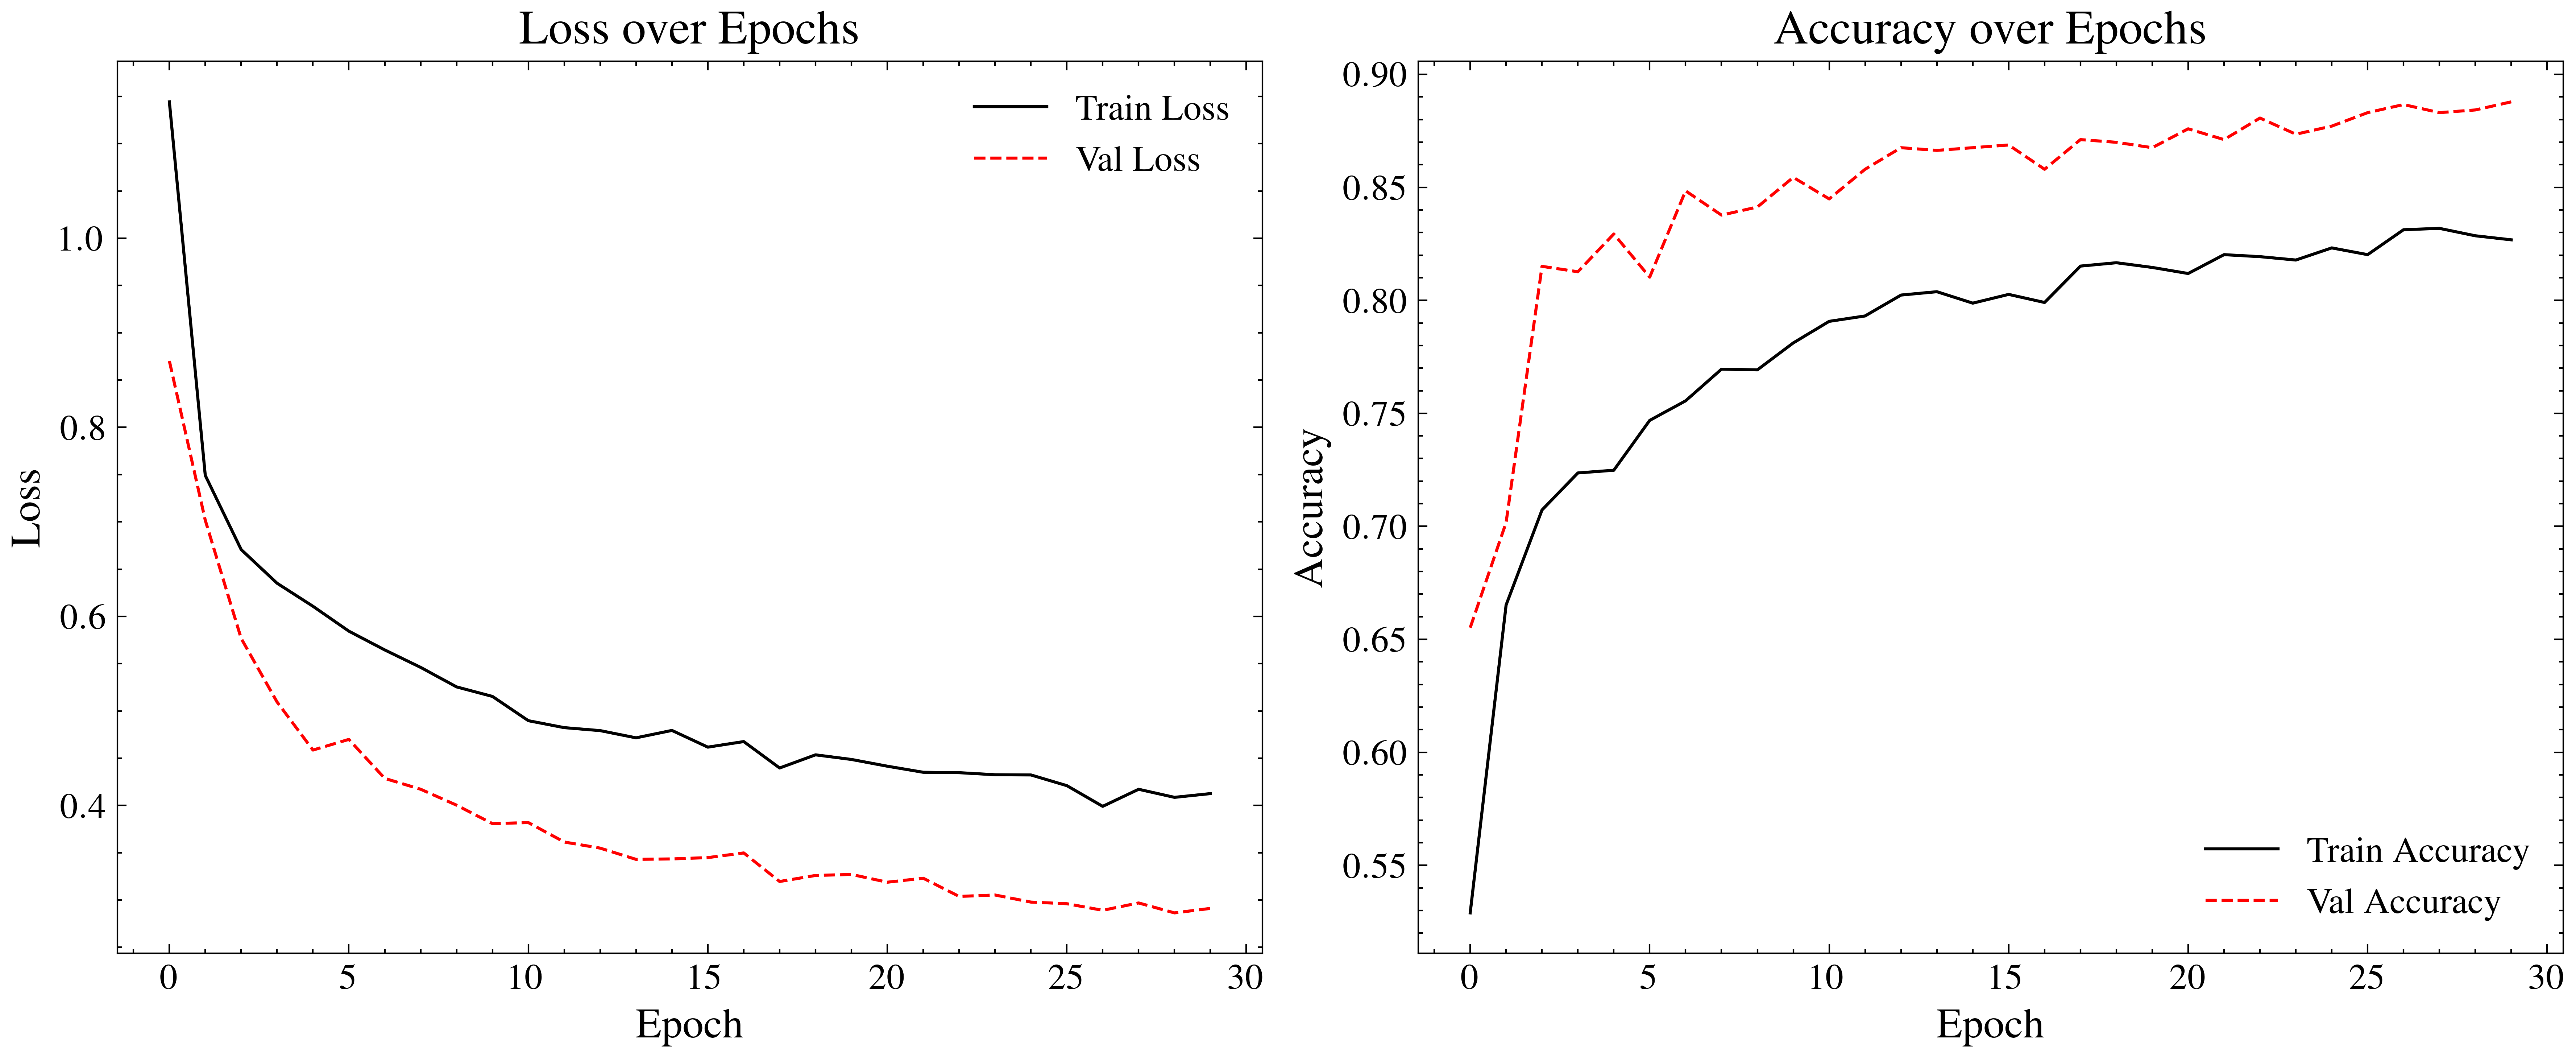

In [355]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Evaluate on Val Data

In [356]:
# Predict class probabilities
y_val_probs = model.predict(X_val_selected)
# Convert to predicted class labels
y_val_preds = np.argmax(y_val_probs, axis=1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step


In [357]:
print("Test Classification Report:\n")
print(classification_report(y_val, y_val_preds, target_names=genre_label_encoder.classes_))

Test Classification Report:

              precision    recall  f1-score   support

      comedy       0.88      0.94      0.91       324
 documentary       0.85      0.89      0.87       296
      horror       0.91      0.82      0.86       428

    accuracy                           0.88      1048
   macro avg       0.88      0.89      0.88      1048
weighted avg       0.88      0.88      0.88      1048



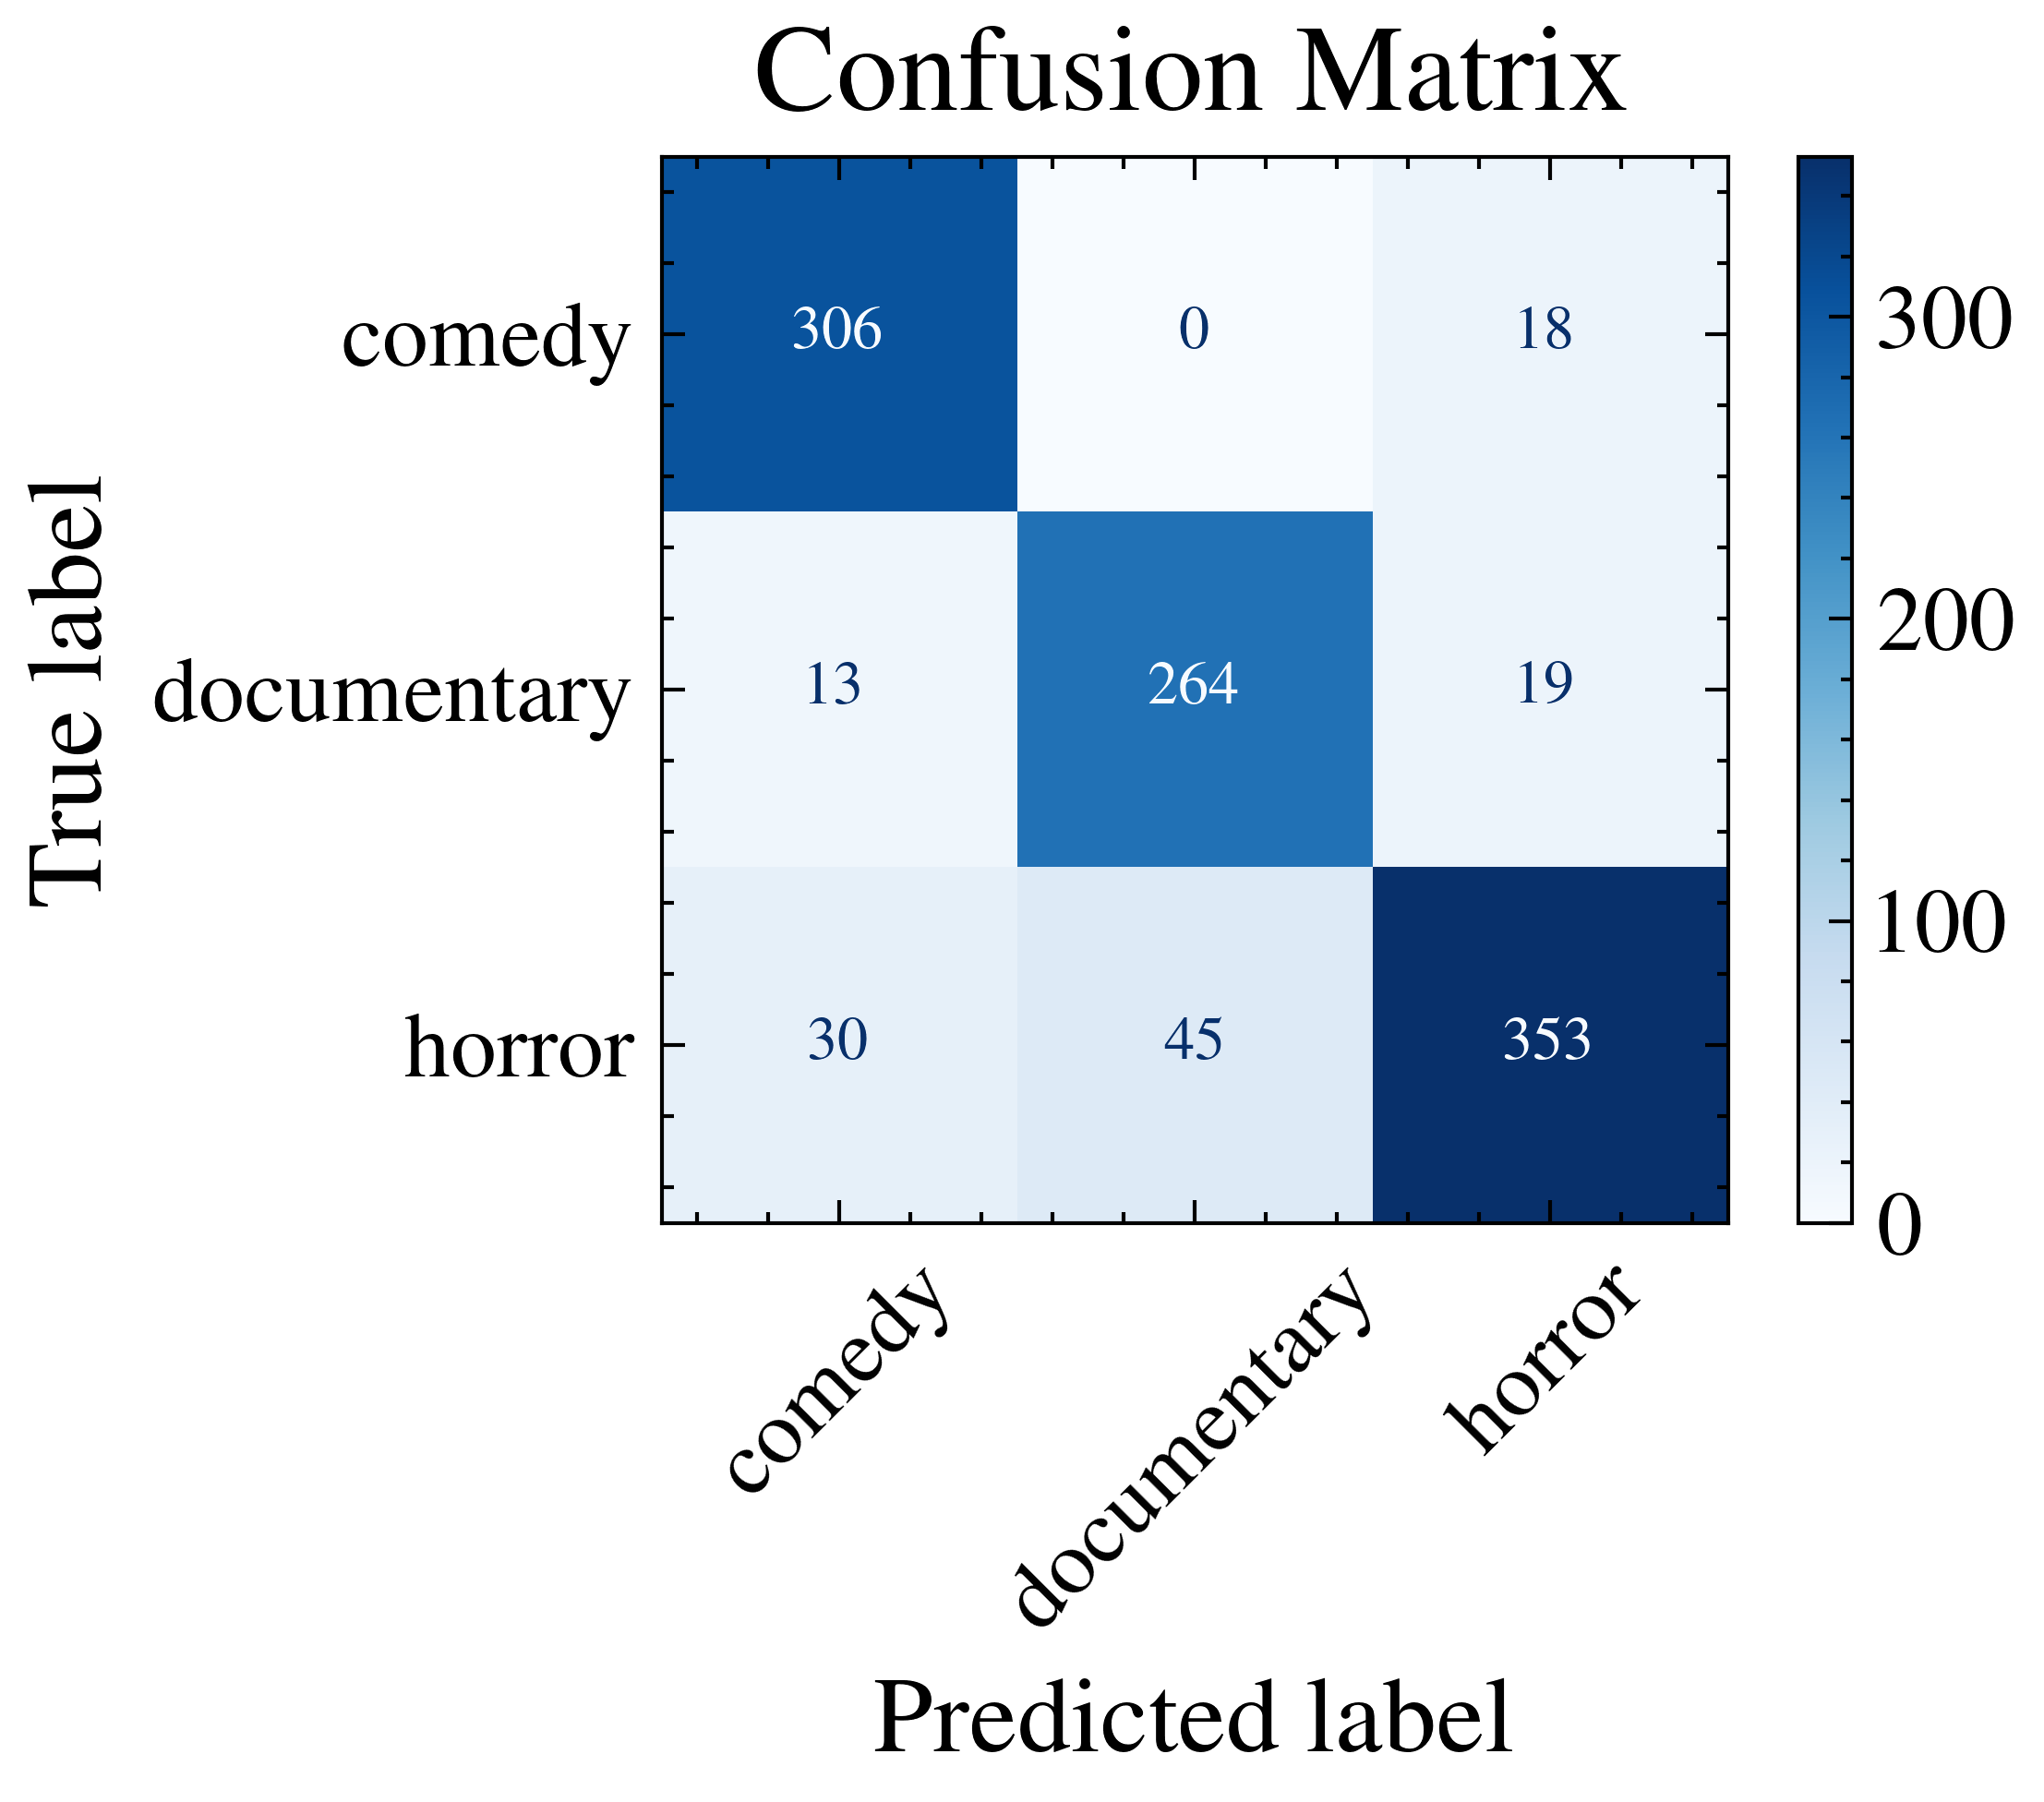

In [358]:
cm = confusion_matrix(y_val, y_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


## Evaluate on test data

In [359]:
# Predict class probabilities
y_test_probs = model.predict(X_test_selected)
# Convert to predicted class labels
y_test_preds = np.argmax(y_test_probs, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 212us/step


In [360]:
print("Test Classification Report:\n")
print(classification_report(y_test, y_test_preds, target_names=genre_label_encoder.classes_))


Test Classification Report:

              precision    recall  f1-score   support

      comedy       1.00      0.00      0.00      1340
 documentary       0.51      0.73      0.60      1560
      horror       0.65      1.00      0.78      1216

    accuracy                           0.57      4116
   macro avg       0.72      0.58      0.46      4116
weighted avg       0.71      0.57      0.46      4116



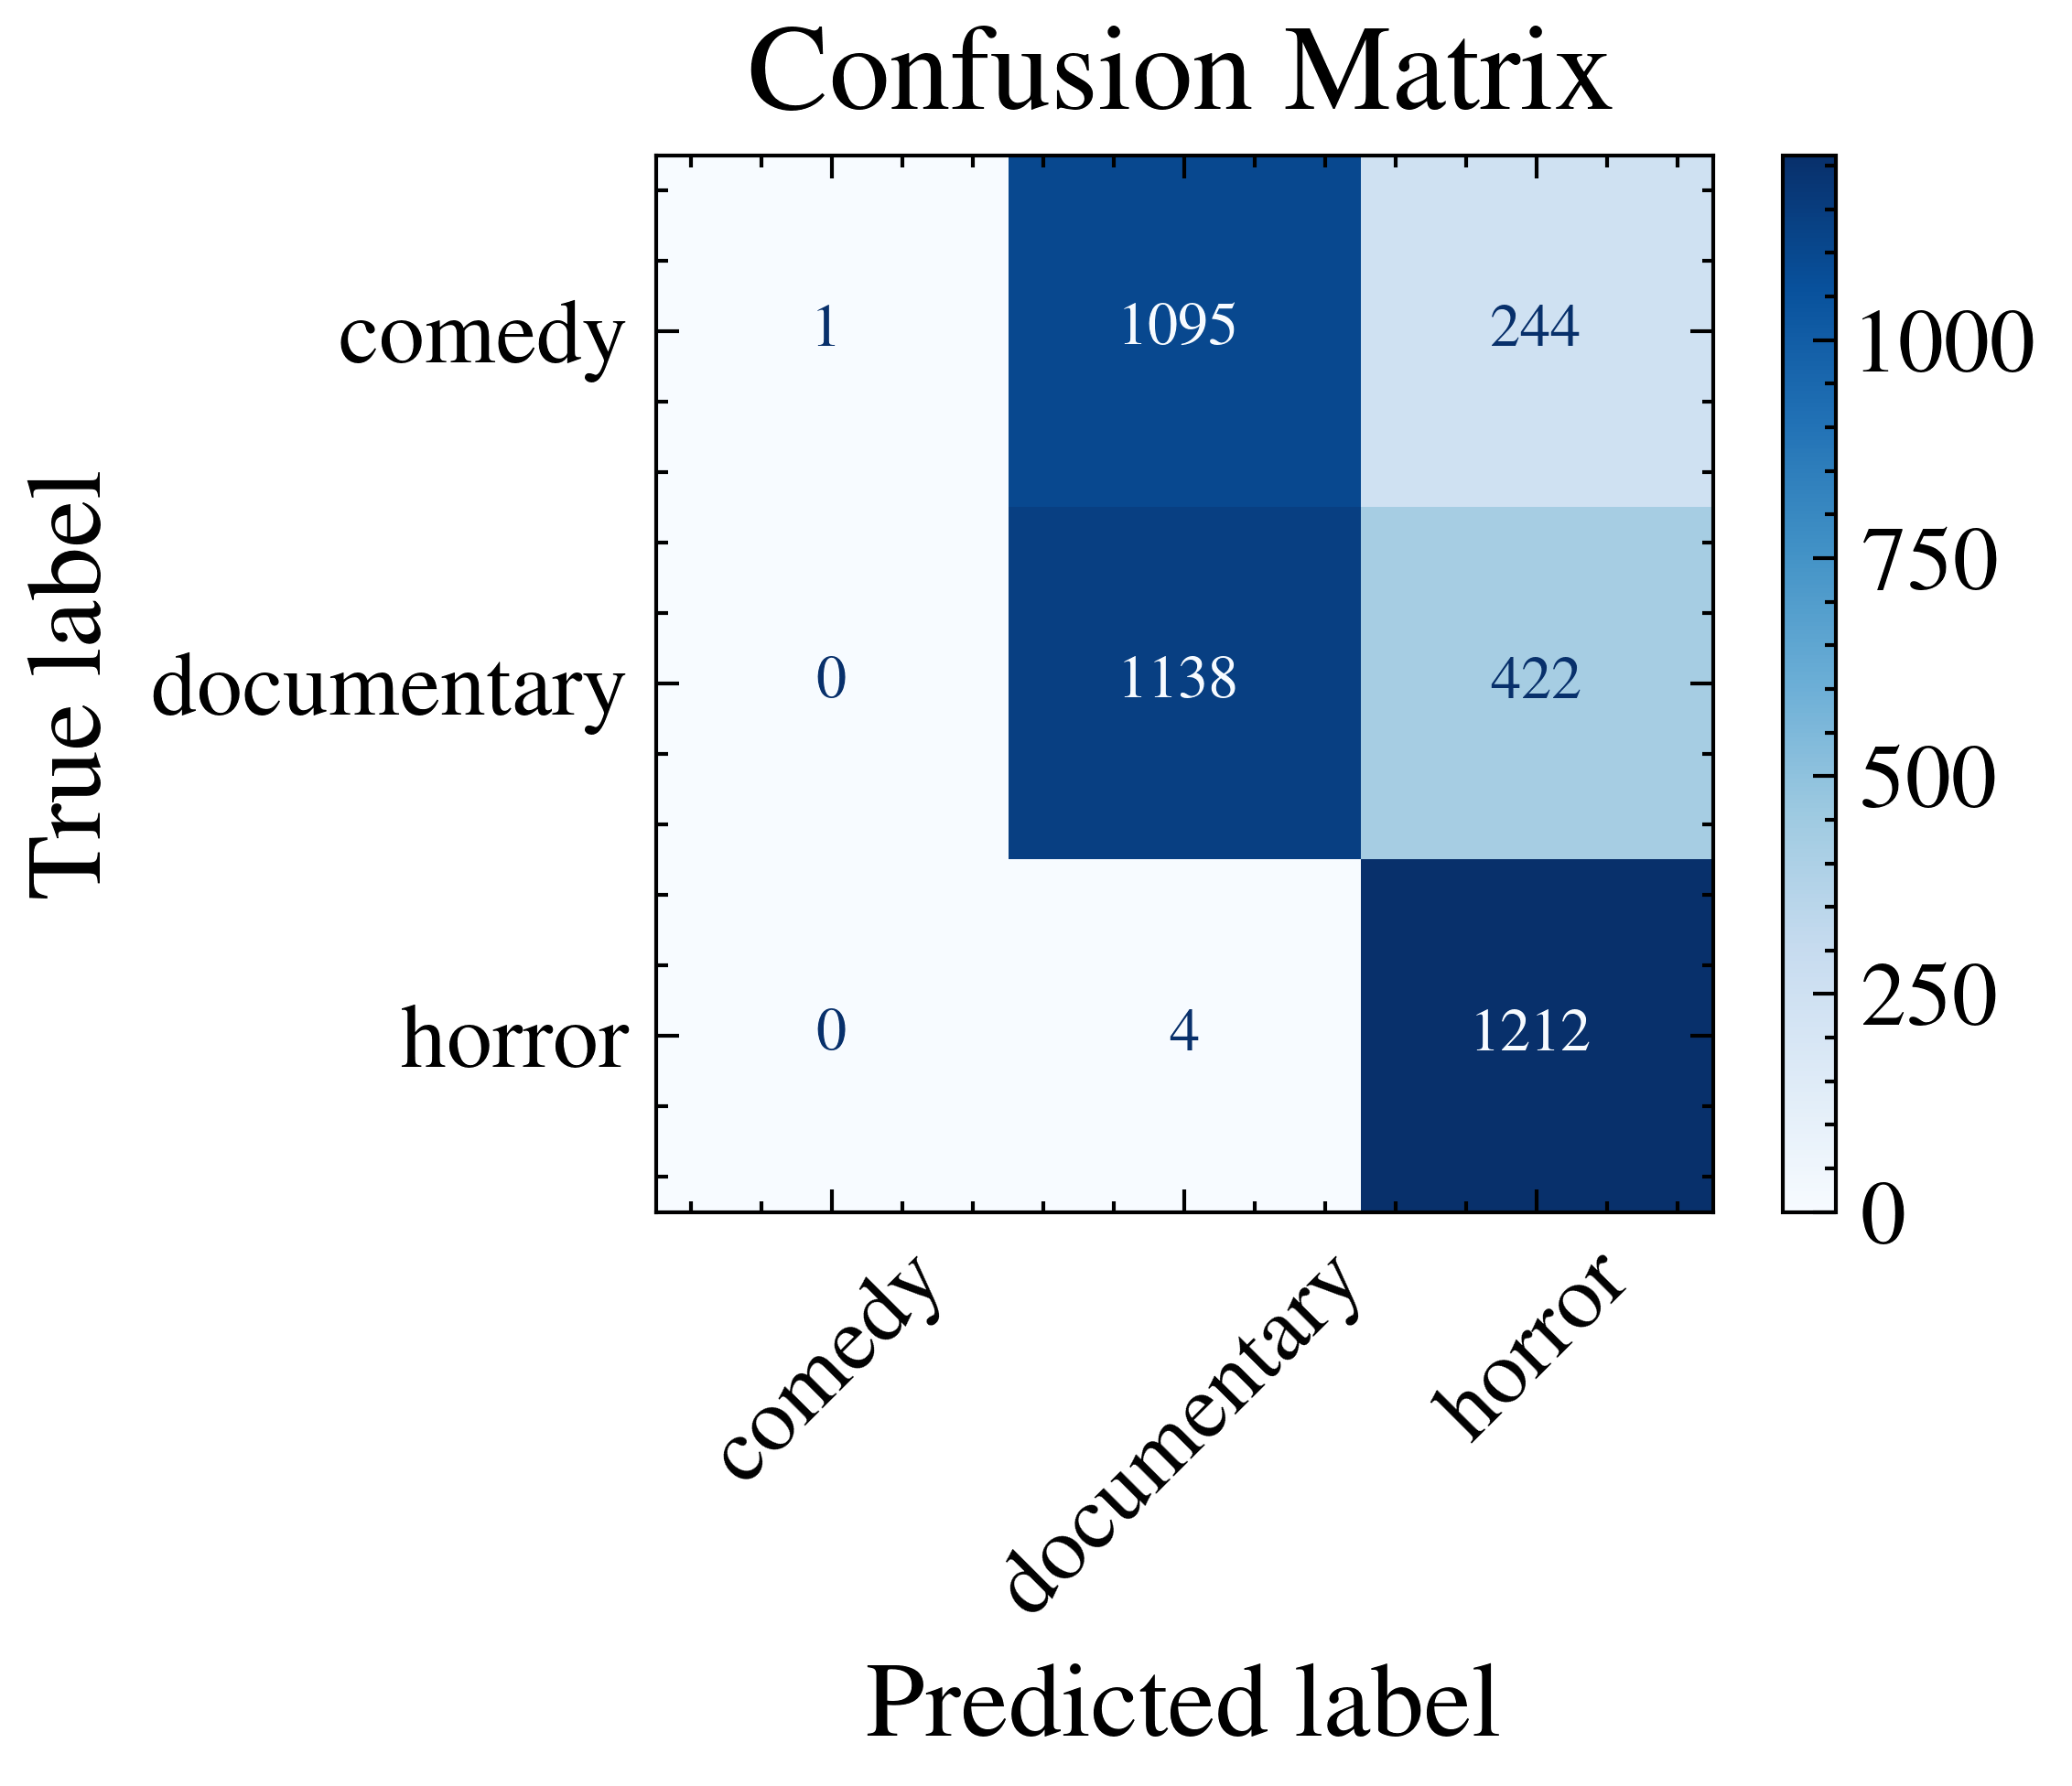

In [362]:
cm = confusion_matrix(y_test, y_test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.savefig("../plots/nn_simple_confusion_matrix.png")
plt.show()
